<a href="https://colab.research.google.com/github/carlos-moreiragit/TC05/blob/main/TC05_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo
O objetivo deste modelo é prever a defasagem escola entre alunos do programa Passos Mágicos. Uma série de modelos foi treinada utilizando os dados de 2024, com o objetivo de prever a defasagem entre os alunos para o próximo ciclo.

# Informaçoes do Dataset

*   Fonte: Passos Mágicos
*   Registros: 952, 8 features, 1 target (1 = defasagem, 0 = sem defasagem)

## Resumo das Fatures

* INDE - Índice de desenvolvimento educacional
* IDADE - Idade do aluno
* IAA - Indicador de autoavaliação
* IEG - Indicador de engajamento
* IPS - Indicador psicossocial
* IPP - Indicador psicopedagógico
* IDA - Indicador de desenvolvimento acadêmico
* IPV - Indicador de ponto de virada


# Monta drive to Google

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount = True)

Mounted at /content/drive


# importações de bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Criação do df

In [ ]:
file_path = '/content/drive/My Drive/POS/PEDE2024.csv'

new_column_names = ['RA', 'INDE', 'IDADE', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'DEFASAGEM', 'ANO']
df = pd.read_csv(file_path, sep=',', usecols=[0, 2, 7, 29, 30, 31, 32, 34, 40, 43, 50], names=new_column_names, header=1)

df.drop(columns=['RA', 'ANO'], inplace=True)

mapping_dafasagem = {0: 0, -1: 1, -2: 1}
df['DEFASAGEM'] = df['DEFASAGEM'].map(mapping_dafasagem)


df['INDE'] = pd.to_numeric(df['INDE'], errors='coerce')
df['IDA'] = pd.to_numeric(df['IDA'], errors='coerce')

df.dropna(inplace = True)

df.head()

,INDE,IDADE,IAA,IEG,IPS,IPP,IDA,IPV,DEFASAGEM
0,8.002867,8,10.0,9.3,3.8,7.5,8.0,7.1,0.0
1,7.952200,8,10.0,9.1,3.8,7.5,8.0,7.0,0.0
2,7.156367,8,8.0,9.8,3.8,6.9,7.0,7.2,1.0
3,5.444200,9,9.0,4.2,3.8,5.0,7.5,4.2,1.0
4,8.082200,9,10.0,10.0,6.3,7.5,8.3,7.8,1.0


In [ ]:
df.shape

(951, 9)

# Exploração/Limpeza dos Dados

## Verificando os tipos de dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 951 entries, 0 to 1049
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   INDE       951 non-null    float64
 1   IDADE      951 non-null    int64  
 2   IAA        951 non-null    float64
 3   IEG        951 non-null    float64
 4   IPS        951 non-null    float64
 5   IPP        951 non-null    float64
 6   IDA        951 non-null    float64
 7   IPV        951 non-null    float64
 8   DEFASAGEM  951 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 74.3 KB


## Checando a distribuição dos dados na coluna target

In [ ]:
df["DEFASAGEM"].value_counts()

,count
DEFASAGEM,
1.0,531
0.0,420


## Verificando estatísticas preliminares

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
INDE,951.0,7.332614,1.001020,3.789478,6.719312,7.473168,8.052283,9.531325
IDADE,951.0,12.119874,2.791403,7.000000,10.000000,12.000000,14.000000,19.000000
IAA,951.0,8.519348,1.545480,0.000000,8.000000,8.800000,9.500000,10.000000
IEG,951.0,8.045110,1.724387,0.000000,7.100000,8.400000,9.400000,10.000000
IPS,951.0,6.821661,1.419983,2.500000,6.300000,7.500000,7.500000,10.000000
IPP,951.0,7.516509,0.898707,2.500000,7.100000,7.500000,8.100000,10.000000
IDA,951.0,6.306519,2.122853,0.000000,4.800000,6.500000,8.000000,10.000000
IPV,951.0,7.294427,1.052606,2.900000,6.700000,7.400000,8.000000,9.800000
DEFASAGEM,951.0,0.558360,0.496844,0.000000,0.000000,1.000000,1.000000,1.000000


## Checando valores nulos

In [ ]:
df.isnull().sum()

,0
INDE,0
IDADE,0
IAA,0
IEG,0
IPS,0
IPP,0
IDA,0
IPV,0
DEFASAGEM,0


## Verificando distribuição e outliers

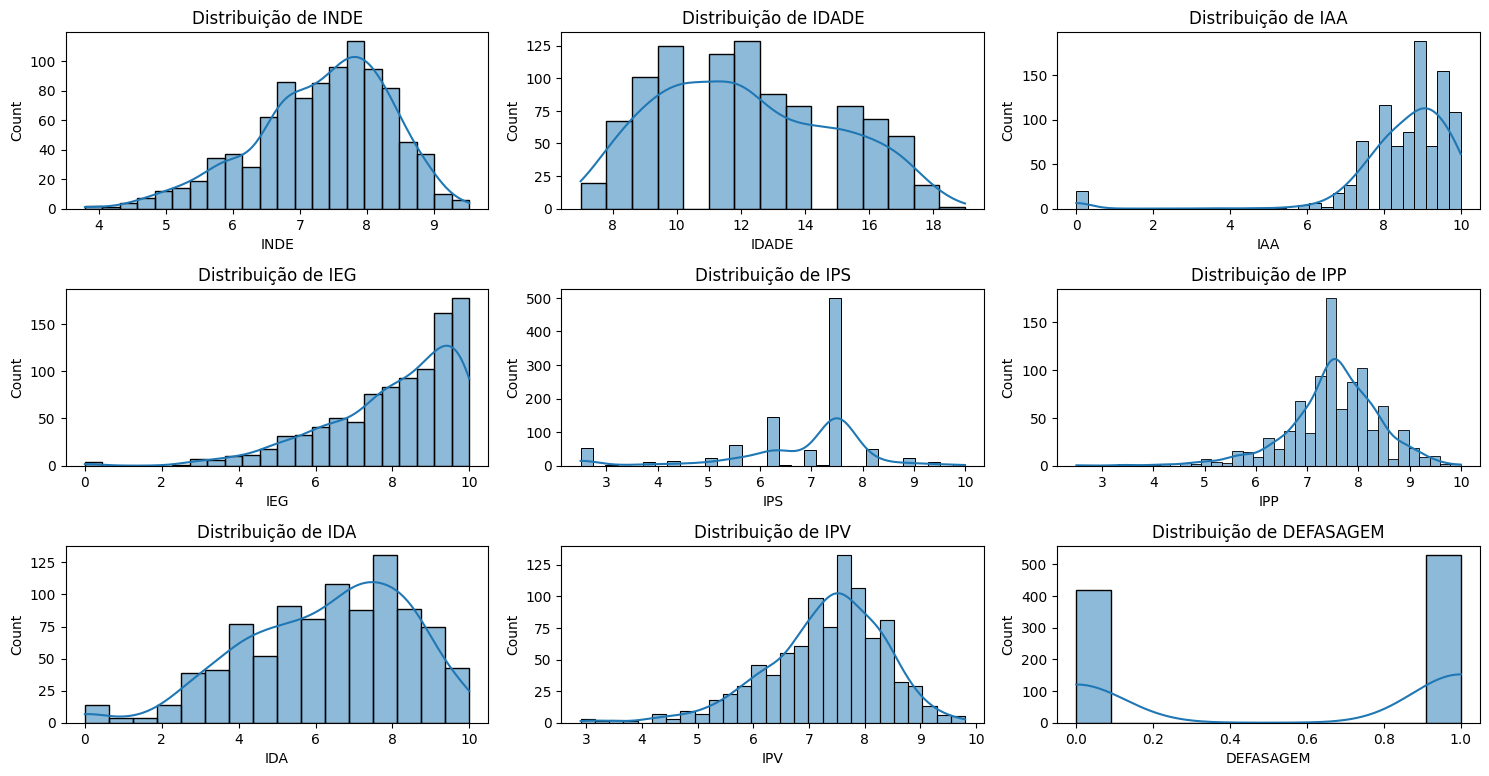

In [ ]:
fig = plt.figure(figsize=(15, 10))
for i,col in enumerate(df.columns, 1):
    plt.subplot(4, 3, i)
    plt.title(f"Distribuição de {col}")
    sns.histplot(df[col], kde = True)

fig.tight_layout()
fig.show()

<Figure size 1500x1000 with 0 Axes>

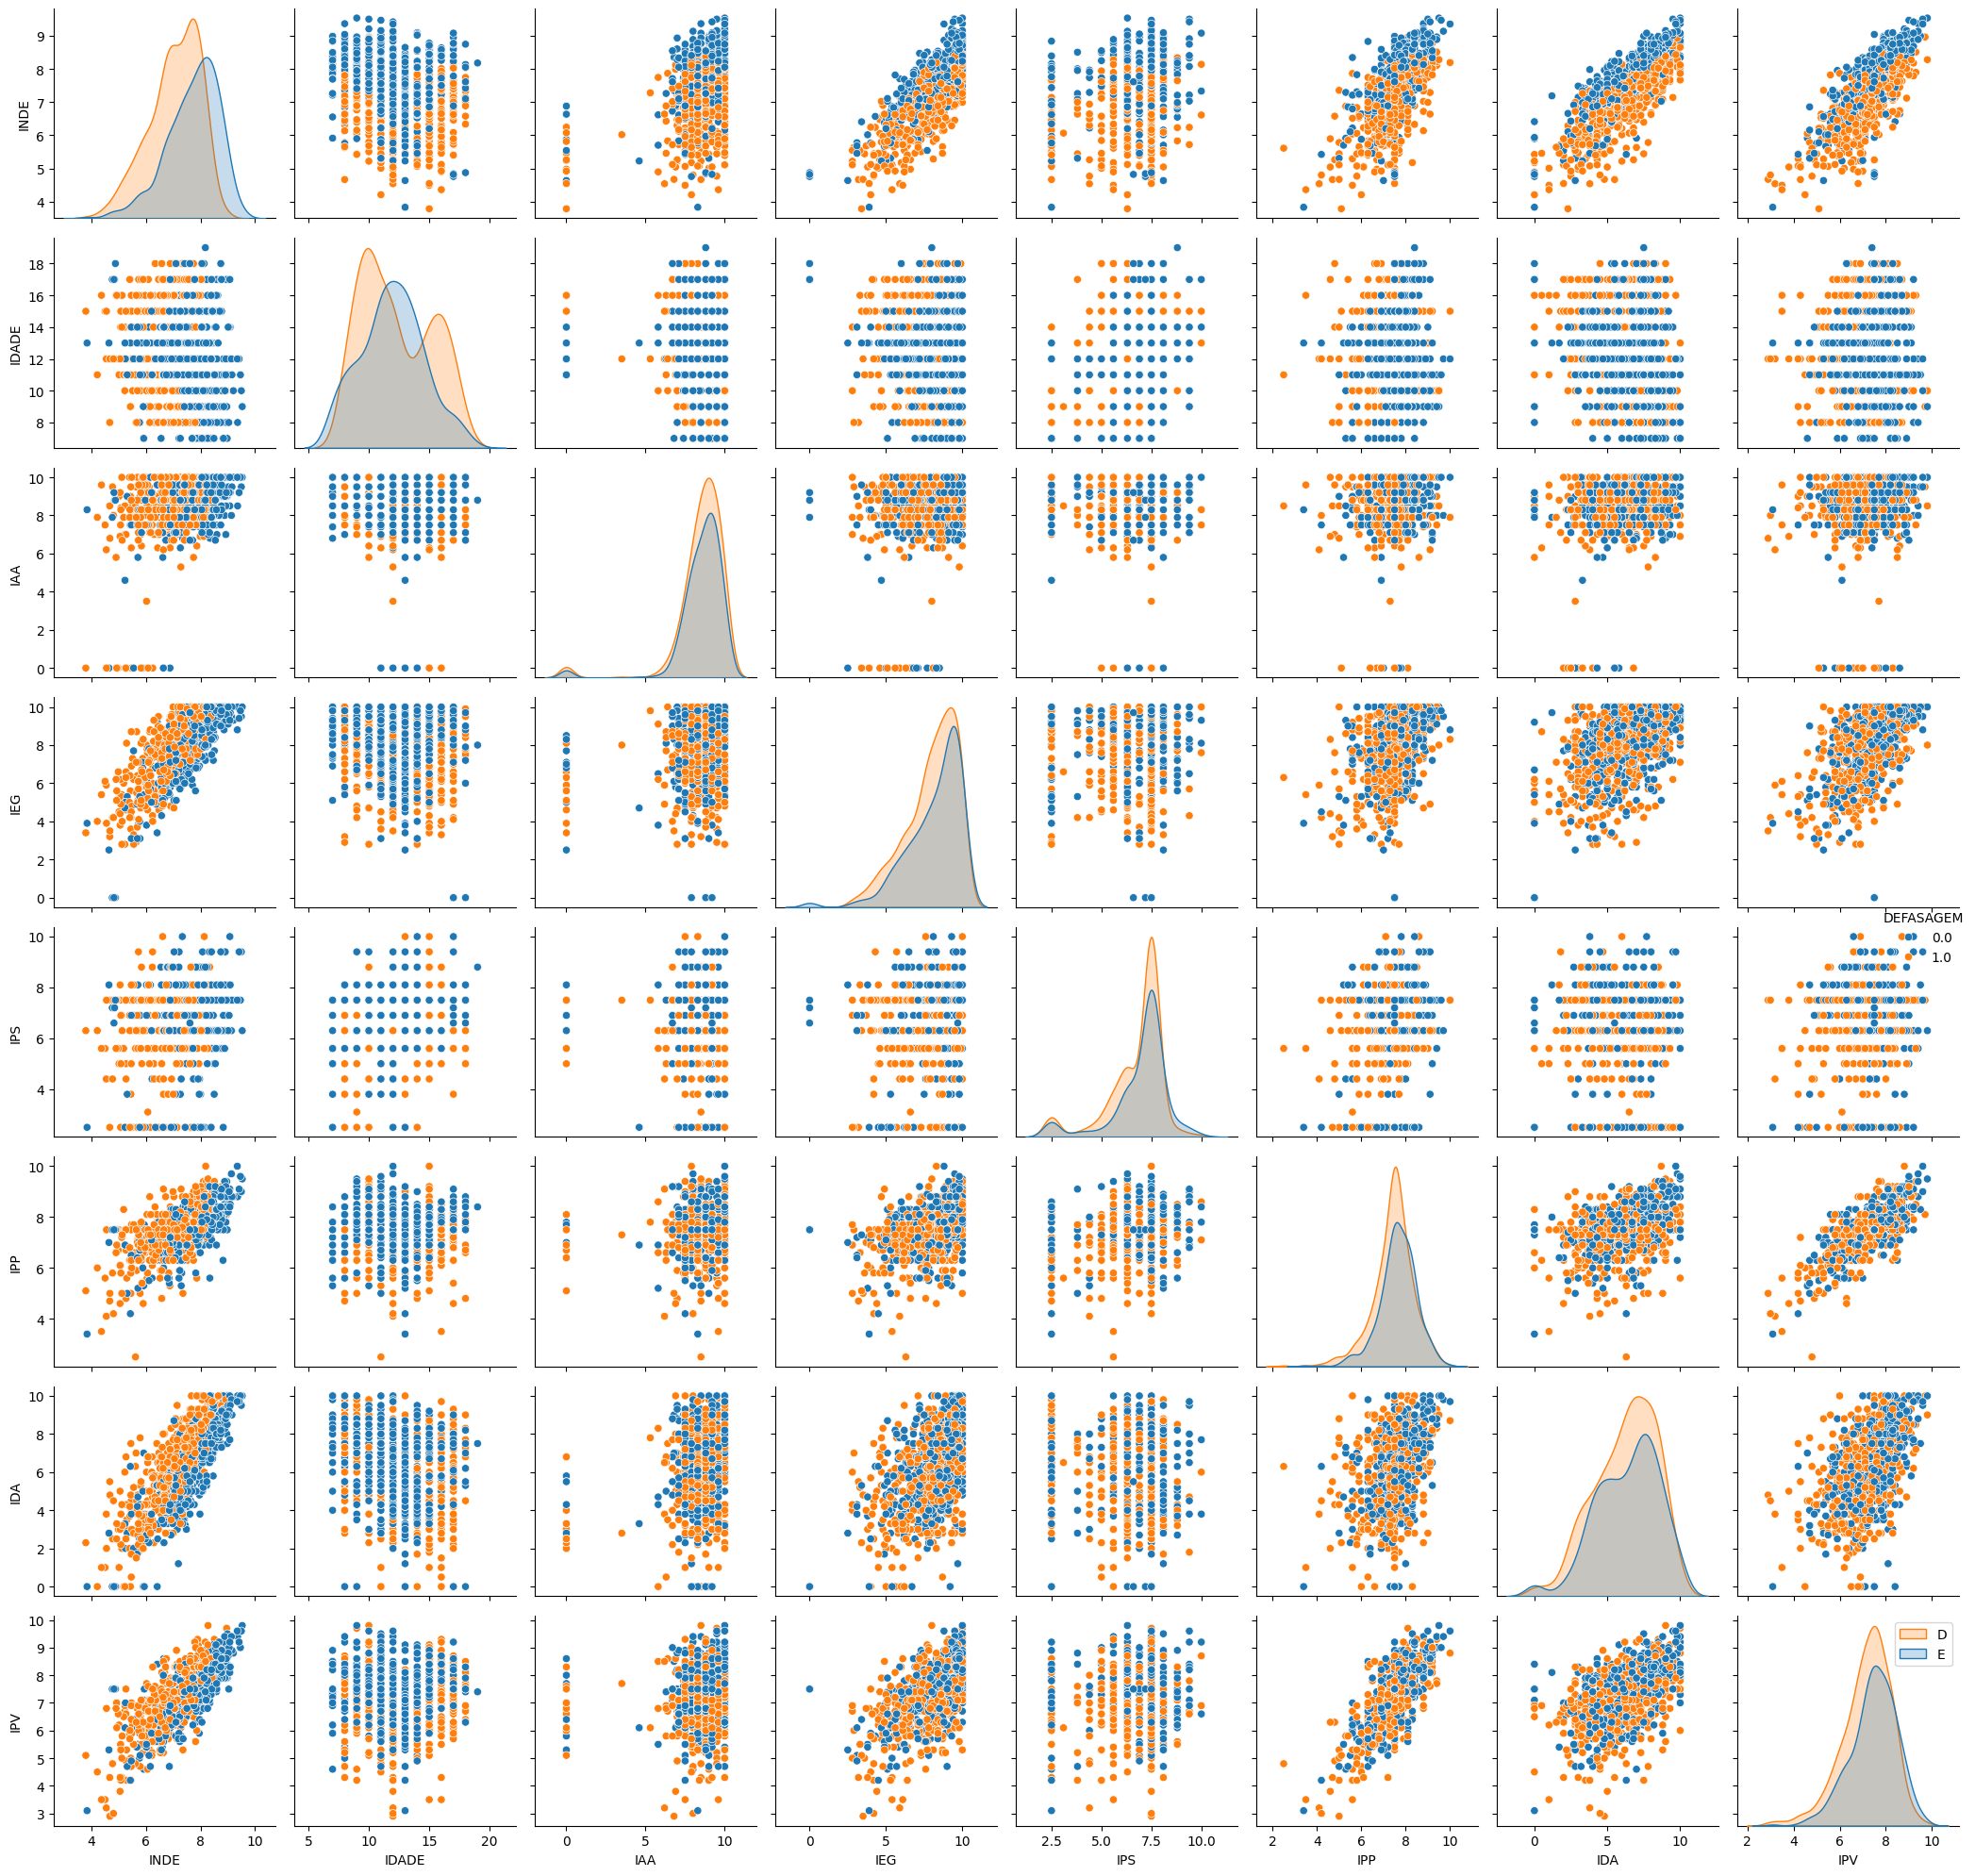

In [ ]:
plt.figure(figsize=(15, 10))
sns.pairplot(df, hue = "DEFASAGEM")
plt.legend("DEFASAGEM")
plt.tight_layout()
plt.show()

## Checando Features Categóricas

Análise para a aplicação do one-hot encoding confirma a possibilidade, uma vez que cada uma das features tem um número baixo de categorias.

In [ ]:
string_col = [col for col in df.columns if df[col].dtype in ["object"]]
for col in string_col:
    print(df[col].value_counts())

# Preparação do Pipeline




## Separando features e target

In [ ]:
X = df.drop("DEFASAGEM", axis = 1)
y = df["DEFASAGEM"]

## Separando Dados para Treino e Teste

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

## Separando features numéricas e categóricas

In [ ]:
numeric_features = [col for col in X_train.columns if X_train[col].dtypes in ["int64", "float64"]]
categorical_features = [col for col in X_train.columns if X_train[col].dtypes in ["object"]]

## Pipeline genérico de pré-processamento

Esse é o pipeline genérico que será utilizado em todos os modelos, aplicando os seguintes tratamentos aos dados:
* Features numéricas: Faltantes ou zeros são substituídos pela mediana e escalados com o RobustScaler, reduzindo assim o efeito dos outliers.
* Features Categóricas: Valores faltes preenchidos com a categoria mais frequente e encodadas usando o OneHotEncoder.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, RobustScaler, OneHotEncoder

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(missing_values = 0, strategy = "median")),
    ("scaler", RobustScaler())
])

# Categorical pipeline
catorical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy = "most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown = "ignore"))
])

# ColumnTransformer
preprocessor_lr = ColumnTransformer([
    ("num", numeric_transformer,numeric_features),
    ("cat", catorical_transformer,categorical_features)
])

## Pipeline de pré-processamento para modelos baseados em árvore

In [ ]:
#preprocessor for tree-based model
preprocessor_treebased = ColumnTransformer([
    ("num", SimpleImputer(missing_values = 0, strategy = "median"), numeric_features),
    ("cat", OrdinalEncoder(handle_unknown = "use_encoded_value", unknown_value= -1), categorical_features)
])

# Treinamento dos Modelos de Classificação Selecionados

Os seguntes modelos foram selacionados para esse caso de uso:
* Dummy Classifier
* Logistic Regression
* K-Nearest Neighbors
* Support Vector Machine
* Decision Tree
* Random Forest
* xgboost


## Setup de cross-validation

Para cross-validation eu selecionei o StratifiedKFold com shuffle=True e n_splits=5



In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

## Treinamento e avaliação de cada modelo (função genérica)

In [ ]:
from sklearn.metrics import classification_report

def cross_val_report(pipe, X_train, y_train):

    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train),1):
        X_train_fold, X_valid_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_valid_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        pipe.fit(X_train_fold, y_train_fold)
        y_val_pred = pipe.predict(X_valid_fold)
        print(f"\nClassification report for fold {fold}:")
        print(classification_report(y_valid_fold, y_val_pred))
        report = classification_report(y_valid_fold, y_val_pred, output_dict=True)
        precision_scores.append(report['weighted avg']['precision'])
        recall_scores.append(report['weighted avg']['recall'])
        f1_scores.append(report['weighted avg']['f1-score'])

    print("\nMédia Ponderada da Acurácia: ",np.mean(precision_scores))
    print("Média Ponderada do recall: ",np.mean(recall_scores))
    print("Média Ponderada f1-score: ",np.mean(f1_scores))

## Baseline model - Dummy classifier

In [ ]:
# DummyClassifier
from sklearn.dummy import DummyClassifier

pipe_dummy = Pipeline([
    ("preprocess", preprocessor_lr),
    ("classifier", DummyClassifier(strategy="stratified"))
])

pipe_dummy.fit(X_train, y_train)
y_pred = pipe_dummy.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.48      0.46      0.47        84
         1.0       0.59      0.61      0.60       107

    accuracy                           0.54       191
   macro avg       0.54      0.54      0.54       191
weighted avg       0.54      0.54      0.54       191



## Regressão Logística

In [ ]:
# LogisticRegression
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("preprocess", preprocessor_lr),
    ("classifier", LogisticRegression(class_weight = "balanced", random_state = 42))
])

# Evaluate with cross-validation
cross_val_report(pipe_lr, X_train,y_train)


Classification report for fold 1:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98        67
         1.0       0.98      1.00      0.99        85

    accuracy                           0.99       152
   macro avg       0.99      0.99      0.99       152
weighted avg       0.99      0.99      0.99       152


Classification report for fold 2:
              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98        67
         1.0       0.97      1.00      0.98        85

    accuracy                           0.98       152
   macro avg       0.98      0.98      0.98       152
weighted avg       0.98      0.98      0.98       152


Classification report for fold 3:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98        67
         1.0       0.98      1.00      0.99        85

    accuracy                           0.99       152
   macro avg       0.99

## KNN

In [ ]:
# KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ("preprocess", preprocessor_lr),
    ("classifier", KNeighborsClassifier(n_neighbors = 5))
])

cross_val_report(pipe_knn, X_train,y_train)


Classification report for fold 1:
              precision    recall  f1-score   support

         0.0       0.78      0.64      0.70        67
         1.0       0.75      0.86      0.80        85

    accuracy                           0.76       152
   macro avg       0.77      0.75      0.75       152
weighted avg       0.77      0.76      0.76       152


Classification report for fold 2:
              precision    recall  f1-score   support

         0.0       0.58      0.63      0.60        67
         1.0       0.68      0.64      0.66        85

    accuracy                           0.63       152
   macro avg       0.63      0.63      0.63       152
weighted avg       0.64      0.63      0.63       152


Classification report for fold 3:
              precision    recall  f1-score   support

         0.0       0.89      0.72      0.79        67
         1.0       0.81      0.93      0.86        85

    accuracy                           0.84       152
   macro avg       0.85

## SVM

In [ ]:
# SVM
from sklearn.svm import SVC

pipe_svc = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", SVC(kernel = 'rbf', probability = True, class_weight = "balanced"))
])

cross_val_report(pipe_svc,X_train,y_train)


Classification report for fold 1:
              precision    recall  f1-score   support

         0.0       0.98      0.91      0.95        67
         1.0       0.93      0.99      0.96        85

    accuracy                           0.95       152
   macro avg       0.96      0.95      0.95       152
weighted avg       0.96      0.95      0.95       152


Classification report for fold 2:
              precision    recall  f1-score   support

         0.0       0.97      0.90      0.93        67
         1.0       0.92      0.98      0.95        85

    accuracy                           0.94       152
   macro avg       0.94      0.94      0.94       152
weighted avg       0.94      0.94      0.94       152


Classification report for fold 3:
              precision    recall  f1-score   support

         0.0       0.98      0.91      0.95        67
         1.0       0.93      0.99      0.96        85

    accuracy                           0.95       152
   macro avg       0.96

## Decision Tree

In [ ]:
#DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline([
    ("preprocess", preprocessor_treebased),
    ("classifier", DecisionTreeClassifier(class_weight = "balanced", random_state = 42))
])

cross_val_report(pipe_dt,X_train, y_train)


Classification report for fold 1:
              precision    recall  f1-score   support

         0.0       0.79      0.78      0.78        67
         1.0       0.83      0.84      0.83        85

    accuracy                           0.81       152
   macro avg       0.81      0.81      0.81       152
weighted avg       0.81      0.81      0.81       152


Classification report for fold 2:
              precision    recall  f1-score   support

         0.0       0.76      0.70      0.73        67
         1.0       0.78      0.82      0.80        85

    accuracy                           0.77       152
   macro avg       0.77      0.76      0.76       152
weighted avg       0.77      0.77      0.77       152


Classification report for fold 3:
              precision    recall  f1-score   support

         0.0       0.76      0.85      0.80        67
         1.0       0.87      0.79      0.83        85

    accuracy                           0.82       152
   macro avg       0.82

## Random Forest

In [ ]:
# RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("preprocess", preprocessor_treebased),
    ("classifier", RandomForestClassifier(class_weight = "balanced", random_state = 42))
])

cross_val_report(pipe_rf, X_train,y_train)


Classification report for fold 1:
              precision    recall  f1-score   support

         0.0       0.85      0.67      0.75        67
         1.0       0.78      0.91      0.84        85

    accuracy                           0.80       152
   macro avg       0.81      0.79      0.79       152
weighted avg       0.81      0.80      0.80       152


Classification report for fold 2:
              precision    recall  f1-score   support

         0.0       0.79      0.69      0.74        67
         1.0       0.78      0.86      0.82        85

    accuracy                           0.78       152
   macro avg       0.78      0.77      0.78       152
weighted avg       0.78      0.78      0.78       152


Classification report for fold 3:
              precision    recall  f1-score   support

         0.0       0.96      0.79      0.87        67
         1.0       0.86      0.98      0.91        85

    accuracy                           0.89       152
   macro avg       0.91

## Xgboost

In [ ]:
# XGBClassifier
from xgboost import XGBClassifier

pipe_xgb = Pipeline([
    ("preprocess", preprocessor_treebased),
    ("classifier", XGBClassifier(class_weight = "balanced", random_state = 42))
])

cross_val_report(pipe_xgb, X_train,y_train)


Classification report for fold 1:
              precision    recall  f1-score   support

         0.0       0.88      0.76      0.82        67
         1.0       0.83      0.92      0.87        85

    accuracy                           0.85       152
   macro avg       0.85      0.84      0.84       152
weighted avg       0.85      0.85      0.85       152


Classification report for fold 2:
              precision    recall  f1-score   support

         0.0       0.88      0.87      0.87        67
         1.0       0.90      0.91      0.90        85

    accuracy                           0.89       152
   macro avg       0.89      0.89      0.89       152
weighted avg       0.89      0.89      0.89       152


Classification report for fold 3:
              precision    recall  f1-score   support

         0.0       0.97      0.90      0.93        67
         1.0       0.92      0.98      0.95        85

    accuracy                           0.94       152
   macro avg       0.94

## Sumário da cross-validation

### Logistic Regression
* Média Ponderada da Acurácia:  0.9847349185909529
* Média Ponderada do recall:  0.9842277261781905
* Média Ponderada f1-score:  0.9841863502828264
### KNN
* Média Ponderada da Acurácia:  0.7111300748600182
* Média Ponderada do recall:  0.7122291021671826
* Média Ponderada f1-score:  0.7109017887649648
### SVM
* Média Ponderada da Acurácia:  0.9597086991450876
* Média Ponderada do recall:  0.9592449260405917
* Média Ponderada f1-score:  0.9591462758940169
### Decision Tree
* Média Ponderada da Acurácia:  0.7752318282518095
* Média Ponderada do recall:  0.7739422084623323
* Média Ponderada f1-score:  0.7733982857079034
### Random Forest
* Média Ponderada da Acurácia:  0.8451842247399972
* Média Ponderada do recall:  0.841013071895425
* Média Ponderada f1-score:  0.8391497153526025
### XGBoost
* Média Ponderada da Acurácia:  0.9296469389876251
* Média Ponderada do recall:  0.9290419676642587
* Média Ponderada f1-score:  0.9288358791361577

# Analisando a Matriz de Confusão

In [ ]:
models = [
    ("DummyClassifier", pipe_dummy),
    ("Logistic Regression", pipe_lr),
    ("KNN", pipe_knn),
    ("SVM", pipe_svc),
    ("Decision Tree", pipe_dt),
    ("Random Forest", pipe_rf),
    ("XGboost", pipe_xgb)
]

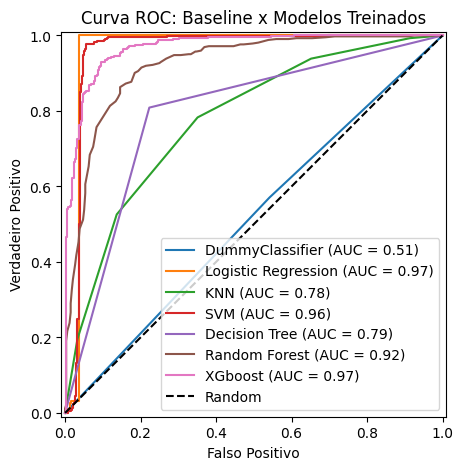

In [ ]:
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_val_predict

plt.figure(figsize=(8, 5), facecolor="white")
ax = plt.gca()

for name, model in models:
        y_proba = cross_val_predict(model, X_train, y_train, cv=cv, method = "predict_proba")[:, 1]
        RocCurveDisplay.from_predictions(y_train, y_proba, name = name, ax = ax)

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel("Falso Positivo")
plt.ylabel("Verdadeiro Positivo")
plt.title("Curva ROC: Baseline x Modelos Treinados")
plt.legend(loc="lower right")
plt.grid(True, color="white", linewidth=0.7, alpha=0.7)
plt.show()

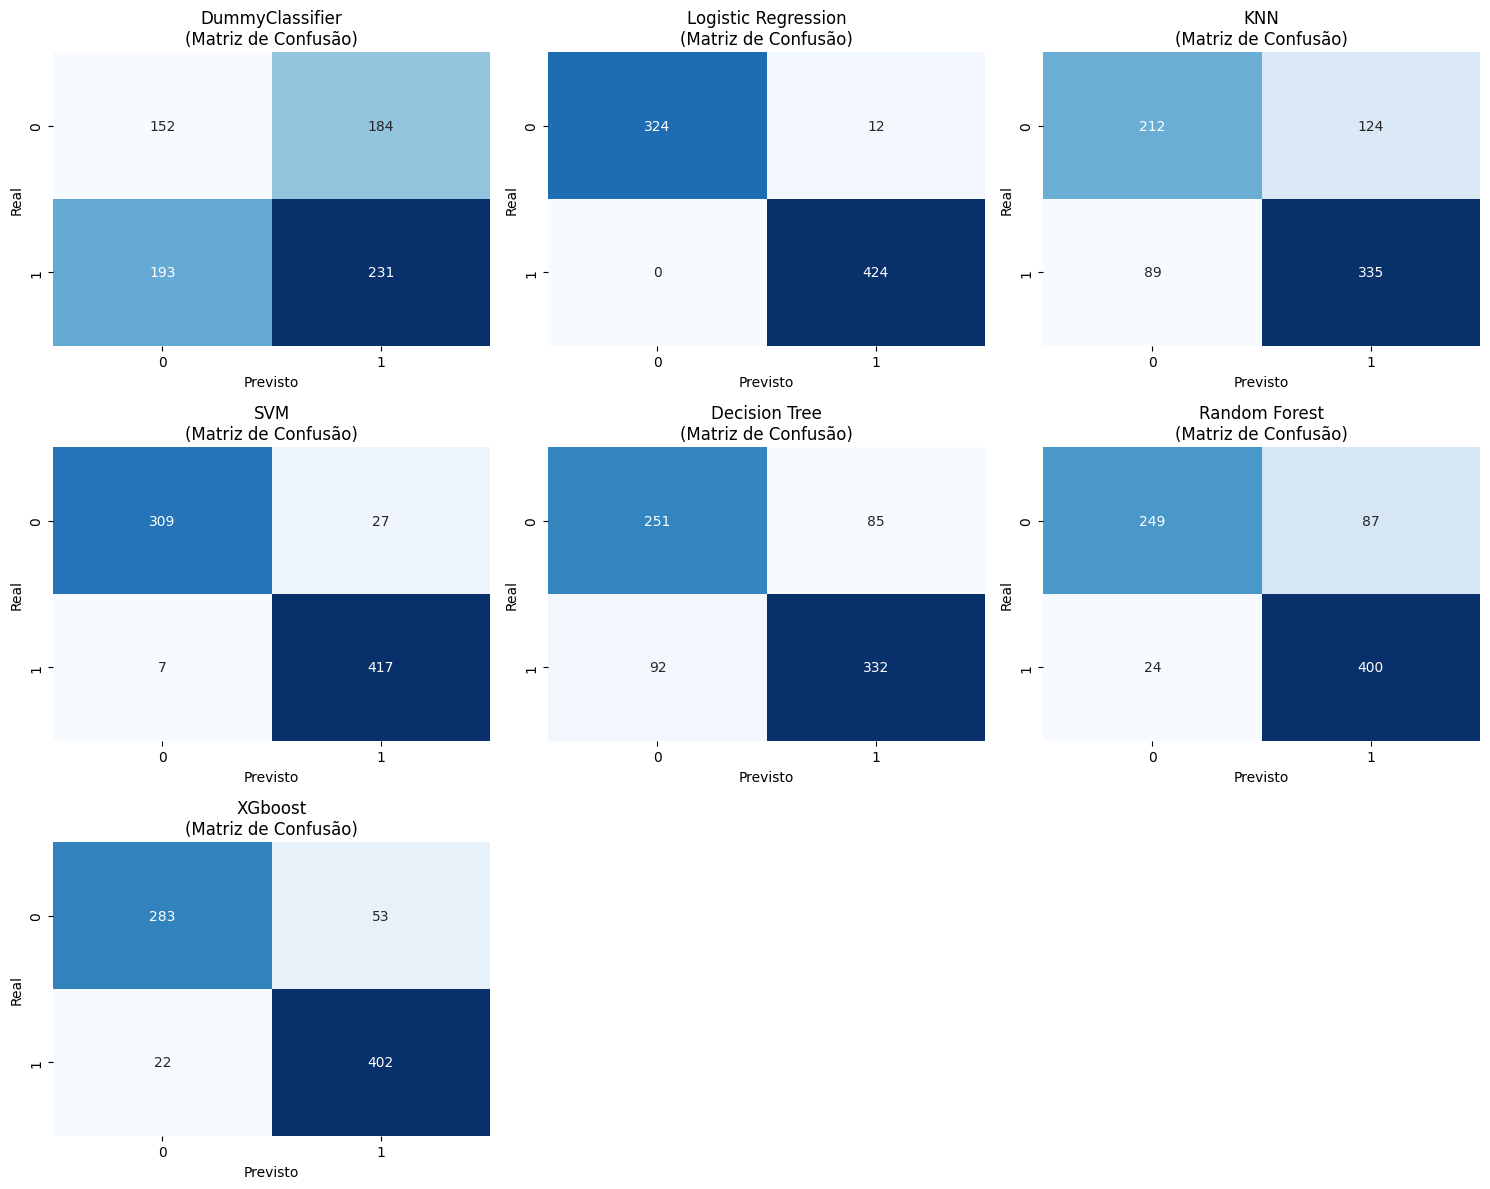

In [ ]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for (name, model), ax in zip(models, axes):
    y_pred = cross_val_predict(model, X_train, y_train, cv = 5, method = "predict")
    cm = confusion_matrix(y_train, y_pred)

    sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", cbar = False, ax = ax)
    ax.set_title(f"{name}\n(Matriz de Confusão)")
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")

# delete subplot not ues
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Tunning de Hyperparametros dos modelos selecionados

Baseado nas análises da curva ROC e da Matriz de Confusão, os seguntes modelos foram selecionados para tunning utilizando o GridSearchCV:

* SVM
* Random Forest



## SVM

In [ ]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

scoring = {
    "precision": make_scorer(precision_score, average = "weighted", zero_division = 0),
    "recall": make_scorer(recall_score, average = "weighted", zero_division = 0),
    "f1": make_scorer(f1_score, average = "weighted", zero_division = 0)
}

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_svc = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__gamma": ["scale", "auto", 0.01, 0.1, 1]
}

grid_svc = GridSearchCV(pipe_svc, param_grid_svc, cv=cv, scoring=scoring, refit="f1", n_jobs=-1)

In [ ]:
grid_svc.fit(X_train, y_train)
print("SVM Best params:", grid_svc.best_params_)
print("SVM mean precision (CV):", grid_svc.cv_results_['mean_test_precision'][grid_svc.best_index_])
print("SVM mean recall (CV):", grid_svc.cv_results_['mean_test_recall'][grid_svc.best_index_])
print("SVM mean f1 (CV):", grid_svc.cv_results_['mean_test_f1'][grid_svc.best_index_])

SVM Best params: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
SVM mean precision (CV): 0.9846618567176855
SVM mean recall (CV): 0.9842105263157894
SVM mean f1 (CV): 0.9841751486154072


## Random Forest

In [ ]:
param_grid_rf = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring=scoring, refit="f1", n_jobs=-1)

In [ ]:
grid_rf.fit(X_train, y_train)

print("\nRF Best params:", grid_rf.best_params_)
print("RF mean precision (CV):", grid_rf.cv_results_['mean_test_precision'][grid_rf.best_index_])
print("RF mean recall (CV):", grid_rf.cv_results_['mean_test_recall'][grid_rf.best_index_])
print("RF mean f1 (CV):", grid_rf.cv_results_['mean_test_f1'][grid_rf.best_index_])


RF Best params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
RF mean precision (CV): 0.8611591192461969
RF mean recall (CV): 0.8539473684210526
RF mean f1 (CV): 0.8513778890046091


## Avaliação após o tunning dos hyperparametros

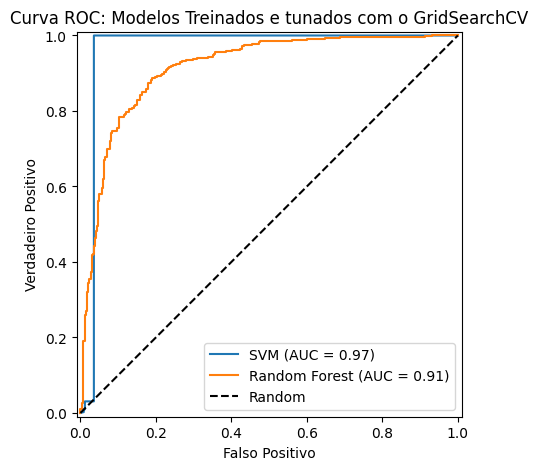

In [ ]:
models_results = [
    ("SVM", grid_svc.best_estimator_),
    ("Random Forest", grid_rf.best_estimator_)
]

plt.figure(figsize=(8, 5), facecolor="white")
ax = plt.gca()

for name, model in models_results:
        y_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
        RocCurveDisplay.from_predictions(y_train, y_proba, name=name, ax=ax)

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel("Falso Positivo")
plt.ylabel("Verdadeiro Positivo")
plt.title("Curva ROC: Modelos Treinados e tunados com o GridSearchCV")
plt.legend(loc="lower right")
plt.grid(True, color="white", linewidth=0.7, alpha=0.7)
plt.show()

## Matriz de Confusão após tunning dos hyperparametros

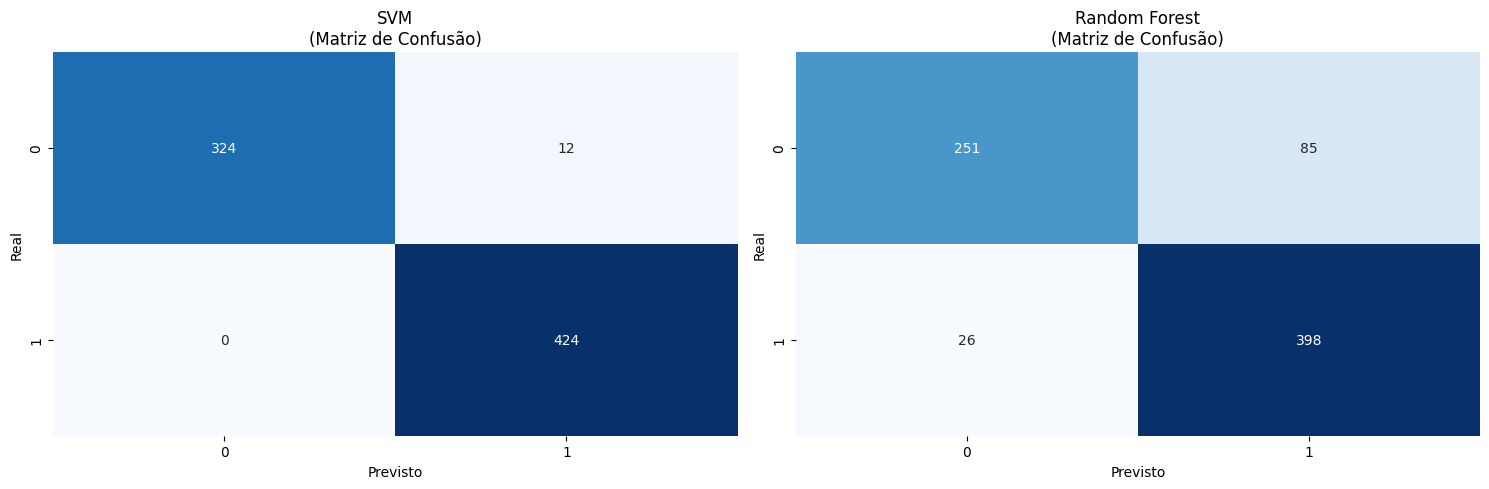

In [ ]:
models = [
    ("SVM", grid_svc.best_estimator_),
    ("Random Forest", grid_rf.best_estimator_)
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.ravel()

for (name, model), ax in zip(models, axes):
    y_pred = cross_val_predict(model, X_train, y_train, cv=5)
    cm = confusion_matrix(y_train, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{name}\n(Matriz de Confusão)")
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

# Seleção do melhor modelo baseado nos resultados - SVM após tunning

O SVM apresentou os melhores resultados no que diz respeito aos falsos negativos, o que é muito importante no nosso contexto, com outras métrica muito aproximadas do Random Forest, portanto foi selecionado como o modelo mais adequado para o nosso caso de uso.

## Avaliação Final do Modelo Selecionado

In [ ]:
selected_svm = grid_svc.best_estimator_

# treinamento
selected_svm.fit(X_train, y_train)

# predict
y_test_pred = selected_svm.predict(X_test)

metrics = ["Acurácia", "Recall", "F1-score"]
scores = [
    precision_score(y_test, y_test_pred),
    recall_score(y_test, y_test_pred),
    f1_score(y_test, y_test_pred)
]

df_bar = pd.DataFrame({
    "Metric" : metrics,
    "Score" : scores
})

fig_bar = px.bar(
    df_bar,
    x = "Metric",
    y = "Score",
    text = "Score",
    color = "Metric",
    title = "SVM Tunado (Test Set)"
)

fig_bar.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig_bar.update_layout(yaxis=dict(range=[0,1]), showlegend=False)
fig_bar.show()

## Matriz de Confusão do Modelo Selecionado

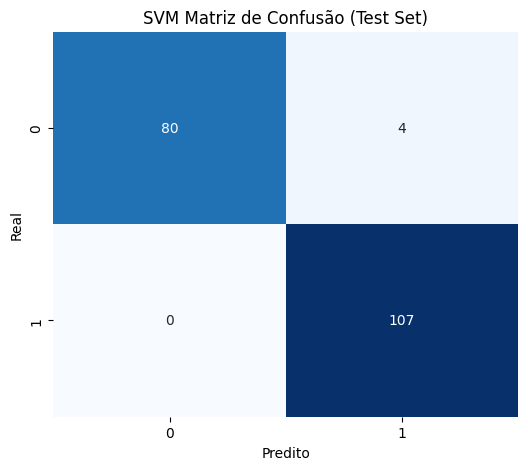

In [ ]:
# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("SVM Matriz de Confusão (Test Set)")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

## Curva ROC do Modelo

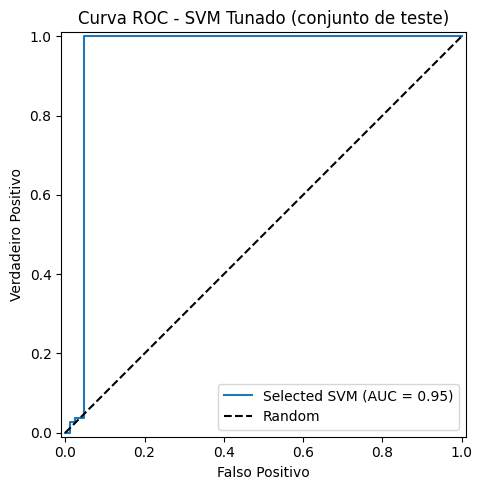

In [ ]:
plt.figure(figsize=(8, 5), facecolor="white")
ax = plt.gca()

y_proba = selected_svm.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba, name="Selected SVM", ax=ax)

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel("Falso Positivo")
plt.ylabel("Verdadeiro Positivo")
plt.title("Curva ROC - SVM Tunado (conjunto de teste)")
plt.legend(loc="lower right")
plt.grid(True, color = "white", linewidth = 0.7, alpha = 0.7)

plt.tight_layout()
plt.show()

## Teste de Overfitting e Generalização do Modelo Selecionado

In [ ]:
# --- Training metrics ---
y_train_pred = selected_svm.predict(X_train)
train_precision = precision_score(y_train, y_train_pred, average='binary')
train_recall = recall_score(y_train, y_train_pred, average='binary')
train_f1 = f1_score(y_train, y_train_pred, average='binary')

# --- Test metrics ---
y_test_pred = selected_svm.predict(X_test)
test_precision = precision_score(y_test, y_test_pred, average='binary')
test_recall = recall_score(y_test, y_test_pred, average='binary')
test_f1 = f1_score(y_test, y_test_pred, average='binary')

# --- Print raw metrics ---
print("Training metrics: Precision={:.3f}, Recall={:.3f}, F1={:.3f}".format(train_precision, train_recall, train_f1))
print("Test metrics:     Precision={:.3f}, Recall={:.3f}, F1={:.3f}".format(test_precision, test_recall, test_f1))

# --- Check overfitting/generalization ---
threshold = 0.05
metrics = ['Precision', 'Recall', 'F1-score']
train_scores = [train_precision, train_recall, train_f1]
test_scores = [test_precision, test_recall, test_f1]

for metric, tr, te in zip(metrics, train_scores, test_scores):
    gap = tr - te
    if gap > threshold:
        status = "Overfitting detected"
    elif gap < -threshold:
        status = "Underfitting detected"
    else:
        status = "Generalizes well"
    print(f"{metric}: Train={tr:.3f}, Test={te:.3f} --> {status}")

Training metrics: Precision=0.972, Recall=1.000, F1=0.986
Test metrics:     Precision=0.964, Recall=1.000, F1=0.982
Precision: Train=0.972, Test=0.964 --> Generalizes well
Recall: Train=1.000, Test=1.000 --> Generalizes well
F1-score: Train=0.986, Test=0.982 --> Generalizes well


## Curva de Aprendizagem do Modelo Selecionado

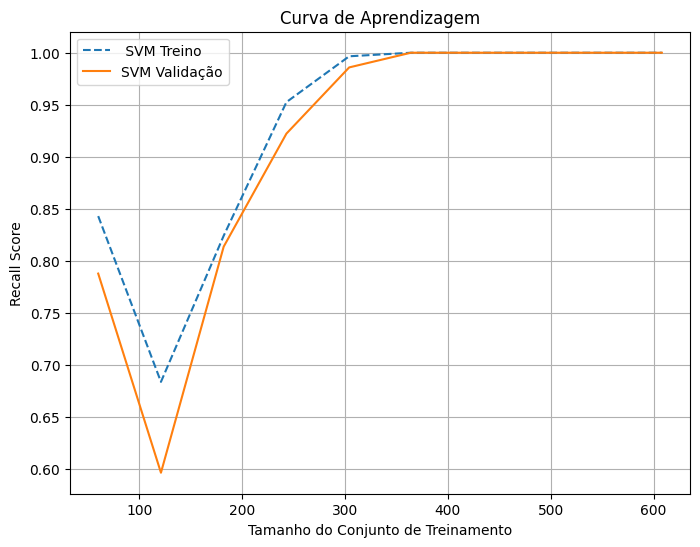

In [ ]:
from sklearn.model_selection import learning_curve

plt.figure(figsize=(8,6))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=selected_svm,
    X=X_train,
    y=y_train,
    cv=5,
    scoring = "recall",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, "--", label=" SVM Treino")
plt.plot(train_sizes, test_mean, "-", label="SVM Validação")

plt.xlabel("Tamanho do Conjunto de Treinamento")
plt.ylabel("Recall Score")
plt.title("Curva de Aprendizagem")
plt.legend()
plt.grid(True)
plt.show()

## Salvando, carregando e testando o Modelo

In [ ]:
import pickle

# Define the file path in Google Drive
model_path = '/content/drive/My Drive/passos.pkl'

# Save the model to the specified path
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Model successfully saved to {model_path}")

Model successfully saved to /content/drive/My Drive/passos.pkl


In [ ]:
# Carrega o modelo saldo no Google Drive

import pickle

# Define the exact same file path
model_path = '/content/drive/My Drive/passos.pkl'

# Load the model from the specified path
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

print(f"Model successfully loaded from {model_path}")

X_test_sample = df.drop("DEFASAGEM", axis=1).head()
y_true_sample = df["DEFASAGEM"].head()
y_pred_sample = model.predict(X_test_sample)

print("True labels:     ", list(y_true_sample.values))
print("Predicted labels:", list(y_pred_sample))

# You can now use the loaded_model for predictions
# predictions = loaded_model.predict(X_test)


Model successfully loaded from /content/drive/My Drive/passos.pkl
True labels:      [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]
Predicted labels: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]


In [ ]:
print(X_test_sample)

       INDE  IDADE   IAA  IEG  IPS  IPP  IDA  IPV
0  7.611367      8  10.0  8.7  6.3  5.6  8.0  5.4
1  8.002867      8  10.0  9.3  3.8  7.5  8.0  7.1
2  7.952200      8  10.0  9.1  3.8  7.5  8.0  7.0
3  7.156367      8   8.0  9.8  3.8  6.9  7.0  7.2
4  5.444200      9   9.0  4.2  3.8  5.0  7.5  4.2
